# Predicting Non-Markovian Dynamics

A control pulse changes a quantum system and its later interaction with the
environment. A surrogate learns that response from simulated sequences, then
predicts reduced system states for new controls. Here we train one small model
and compare a pulse-angle sweep with exact two-qubit evolution.

```{note}
**Experimental feature.** Surrogate modeling is not yet supported by a published
YAQS paper. This small example teaches the workflow; it does not demonstrate a
speed advantage or establish accuracy for longer control sequences. Validate
predictions against simulations or measurements for your intended use.
```

Install the PyTorch extra with `uv pip install "mqt.yaqs[torch]"`. The plot also
uses Matplotlib. Run the cells in order in a notebook; for a script, use the
entry-point guard in {doc}`simulator_initialization`.

## 1. Choose the system and train on random controls

Site 0 is the probe, and site 1 is an environment qubit initially in
$|0\rangle$. Their Hamiltonian is $H=-Z_0Z_1-0.5(X_0+X_1)$, with $\hbar=1$. We
apply two random single-qubit rotations to the probe, each followed by evolution
for $0.6$. The environment can retain information about the earlier control.

In [1]:
import numpy as np
import torch

from mqt.yaqs import AnalogSimParams, Hamiltonian, MemoryCharacterizer

interval = 0.6
schedule = [0.0, interval, interval]
hamiltonian = Hamiltonian.ising(2, J=1.0, g=0.5)
params = AnalogSimParams(elapsed_time=interval, dt=interval, preset="fast")
characterizer = MemoryCharacterizer(show_progress=False)

torch.manual_seed(7)
validation = characterizer.sample(
    hamiltonian, params, num_interventions=2, n=128, seed=99,
    timesteps=schedule, intervention_style="haar",
)
model = characterizer.train(
    hamiltonian, params, num_interventions=2, n=2048, seed=7,
    timesteps=schedule, intervention_style="haar",
    model_kwargs={"d_model": 64, "num_layers": 2, "dim_ff": 128},
    train_kwargs={"epochs": 200, "lr": 1e-3, "device": "cpu", "val_dataset": validation},
)

`timesteps` contains the initial delay and one duration after each intervention.
The initial `0.0` places the first rotation immediately after preparation, and
the final time is $1.2$. Training varies the probe preparation and draws random
unitaries with `intervention_style="haar"`; the environment preparation stays
fixed. YAQS restores the model with the lowest validation loss. The validation
set selects the model, so it is not an independent accuracy test.

## 2. Predict a pulse-angle sweep

Prepare the probe in $|+\rangle$. Use the identity as the first control, then
apply $R_z(\theta)$ between the two evolution intervals. These chosen controls
were not supplied during training. At $\theta=0$ the system evolves freely;
$\theta=\pi$ gives a phase flip halfway through.

In [2]:
plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
rho0 = np.outer(plus, plus.conj())
identity = np.eye(2, dtype=complex)
pulse_angles = np.linspace(0, 2 * np.pi, 41)
sequences = [
    [
        {"unitary": identity},
        {"unitary": np.diag(np.exp(-0.5j * angle * np.array([1, -1])))},
    ]
    for angle in pulse_angles
]
predicted = np.stack([
    characterizer.predict(model, rho0, sequence) for sequence in sequences
])

`predict` returns a complex `(2, 2)` density-matrix estimate. Stacking the sweep
produces shape `(41, 2, 2)`. All entries describe the same final time, not a
trajectory through time.

(short-horizon-validation)=

## 3. Check against exact evolution

For two qubits, SciPy's matrix exponential gives a cheap reference independent
of YAQS's solvers. Site 0 is the least significant bit, so the joint initial
state is $|0\rangle_{\mathrm{env}}\otimes|+\rangle_{\mathrm{probe}}$ and a probe
pulse acts as $I\otimes R_z(\theta)$. Tracing out the environment gives the
reference probe state.

In [3]:
from scipy.linalg import expm

pauli_x = np.array([[0, 1], [1, 0]], dtype=complex)
pauli_z = np.diag([1.0, -1.0])
dense_hamiltonian = -np.kron(pauli_z, pauli_z) - 0.5 * (
    np.kron(identity, pauli_x) + np.kron(pauli_x, identity)
)
evolution = expm(-1j * interval * dense_hamiltonian)
initial_joint = np.kron([1, 0], plus)
states = []
for sequence in sequences:
    joint = evolution @ np.kron(identity, sequence[1]["unitary"]) @ evolution @ initial_joint
    amplitudes = joint.reshape(2, 2)
    states.append(amplitudes.T @ amplitudes.conj())
reference = np.stack(states)

matrix_errors = 0.5 * np.sum(np.abs(np.linalg.eigvalsh(predicted - reference)), axis=1)
trace_error = np.max(np.abs(np.trace(predicted, axis1=1, axis2=2) - 1))
minimum_eigenvalue = np.min(np.linalg.eigvalsh(predicted))
print(f"Maximum matrix error: {matrix_errors.max():.4f}")
print(f"Maximum trace error: {trace_error:.4f}; minimum eigenvalue: {minimum_eigenvalue:.4f}")

Maximum matrix error: 0.0823
Maximum trace error: 0.0137; minimum eigenvalue: 0.1237


The matrix error is half the trace norm of the difference. It equals trace
distance when both matrices are normalized physical states. The public API makes
predictions Hermitian but does not enforce unit trace or positivity. The printed
checks expose those limitations; we do not normalize the predictions or clip
negative eigenvalues.

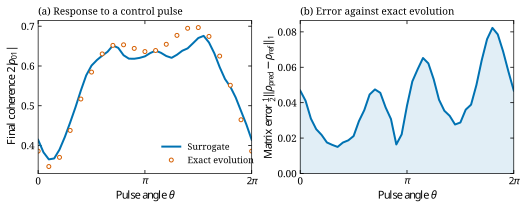

In [4]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["STIXGeneral"], "mathtext.fontset": "stix",
    "font.size": 10, "axes.labelsize": 11, "axes.linewidth": 0.7,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False, "figure.constrained_layout.use": True,
    "savefig.bbox": "tight", "svg.fonttype": "none",
})
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
axes[0].plot(pulse_angles, 2 * np.abs(predicted[:, 0, 1]), color="#0072B2",
             linewidth=2, label="Surrogate")
axes[0].plot(pulse_angles[::2], 2 * np.abs(reference[::2, 0, 1]), "o", color="#D55E00",
             markerfacecolor="white", markersize=4, label="Exact evolution")
axes[0].set_ylabel(r"Final coherence $2|\rho_{01}|$")
axes[0].set_title("(a) Response to a control pulse", loc="left", fontsize=10)
axes[0].legend(fontsize=9)
axes[1].plot(pulse_angles, matrix_errors, color="#0072B2", linewidth=2)
axes[1].fill_between(pulse_angles, 0, matrix_errors, color="#0072B2", alpha=0.12)
axes[1].set_ylabel(r"Matrix error $\frac{1}{2}\|\rho_{\rm pred}-\rho_{\rm ref}\|_1$")
axes[1].set_title("(b) Error against exact evolution", loc="left", fontsize=10)
axes[1].set_ylim(bottom=0)
for ax in axes:
    ax.set(xlabel=r"Pulse angle $\theta$", xlim=(0, 2 * np.pi),
           xticks=[0, np.pi, 2 * np.pi], xticklabels=["0", r"$\pi$", r"$2\pi$"])
plt.show()

An instantaneous $Z$ rotation preserves coherence magnitude when applied. The
variation here arises during subsequent interaction with the environment. The
reference and error panel show how well this small model captures that response.
This training budget keeps the example inexpensive and leaves visible prediction
errors. Results can vary with seeds and PyTorch versions.

## Scope and other options

The model uses a fixed Hamiltonian, environment preparation, and control
schedule. Retrain and validate when those change. The public training path does
not accept a `NoiseModel`, and this two-intervention example does not establish
accuracy for longer protocols.

Use `predict(model, rho0, sequence, return_sequence=True)` to obtain shape
`(num_interventions, 2, 2)`, with one state after each intervention and its
following evolution interval. Sampling and training also support `"clifford"`
and `"measure_prepare"` controls; validate other control families separately.
For environmental memory diagnostics and short process-tensor references, see
{doc}`characterization`.